In [7]:
# parse iperf log
import re
import pandas as pd

def parse_iperf_throughput(path: str) -> pd.DataFrame:
    """
    Parse iperf/iperf3 per-interval lines from `path` and return a DataFrame
    with a single column 'throughput_mbps' (float). Units are normalized to Mbit/s.
    Only per-interval entries are kept (summary sender/receiver lines are skipped).
    """
    # Matches lines like:
    # [  5]   0.00-1.00   sec   339 KBytes  2.78 Mbits/sec
    pat = re.compile(
        r'\[\s*\d+\s*\]\s*'                 # [  5]
        r'[\d.]+\s*-\s*[\d.]+\s*sec\s+'     # 0.00-1.00 sec
        r'.*?'                              # up to throughput
        r'([\d.]+)\s*'                      # throughput value
        r'([KMG]?bits/sec|[KMG]?bit/s)',    # unit (K/M/G)bits/sec or bit/s
        flags=re.IGNORECASE
    )

    unit_factor = {
        'bit/s':      1/1e6,
        'bits/sec':   1/1e6,
        'kbit/s':     1e-3,
        'kbits/sec':  1e-3,
        'mbit/s':     1.0,
        'mbits/sec':  1.0,
        'gbit/s':     1e3,
        'gbits/sec':  1e3,
    }

    thru = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            # Skip summary lines
            low = line.lower()
            if 'sender' in low or 'receiver' in low:
                continue

            m = pat.search(line)
            if not m:
                continue

            val = float(m.group(1))
            unit = m.group(2).lower()
            factor = unit_factor.get(unit)
            if factor is None:
                continue  # unknown unit; ignore safely

            thru.append(val * factor)

    return pd.DataFrame({'throughput_mbps': thru})


In [8]:
ch = parse_iperf_throughput('chronos.log')
cots = parse_iperf_throughput('cots.log')

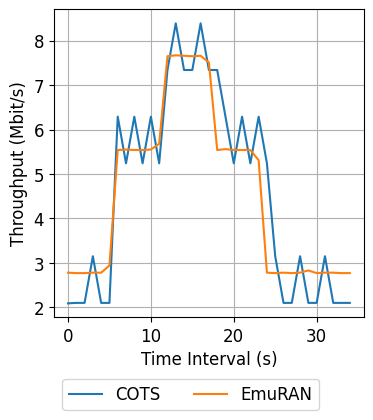

In [37]:
# plot throughput
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))  # Wider figure for 2-column legend
plt.plot(cots.index, cots['throughput_mbps'], label='COTS')
plt.plot(ch.index, ch['throughput_mbps'], label='EmuRAN')

plt.xlabel('Time Interval (s)', fontsize=12)
plt.ylabel('Throughput (Mbit/s)', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# Move legend outside the plot, 2 columns
plt.legend(fontsize=12, loc='center left', bbox_to_anchor=(0, -0.25), ncol=2)

plt.grid()
plt.savefig('throughput_comparison_channel.pdf', dpi=300, bbox_inches='tight')
plt.show()